In [1]:
!pip install scikit-image watermark -q

# Install OpenCV package first
!pip install opencv-python -q

# First install the required system library
!apt-get update && apt-get install -y libgl1-mesa-glx

!pip install opencv-python


[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip
Hit:1 http://deb.debian.org/debian bullseye InRelease
Hit:2 http://deb.debian.org/debian-security bullseye-security InRelease
Hit:3 http://deb.debian.org/debian bullseye-updates InRelease




libgl1-mesa-glx is already the newest version (20.3.5-1).
0 upgraded, 0 newly installed, 0 to remove and 67 not upgraded.

[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Importamos las librerías
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Recorte, extracción y cambio de perspectiva

En esta sección vamos a recortar una de las cartas, extraerla y rotarla para que se vea de frente.

Para eso vamos a:

1. Identificar las cuatros esquinas de la carta en cuestión (Vamos a extraer el rey de picas del frente y rotarlo).
2. Crear una matriz de transformación de cambio perspectiva. Para esto especificaremos los puntos 4 puntos de origen y los 4 puntos de destino y vamos a llamar a `cv2.getPerspectiveTransform(pts1, pts2)` que va a construir la matriz que nos va a servir para realizar esta transformación

In [8]:
!wget https://www.lallama.org/wp-content/uploads/2024/01/Perspectiva.jpg 

--2025-04-30 00:46:58--  https://www.lallama.org/wp-content/uploads/2024/01/Perspectiva.jpg
Resolving www.lallama.org (www.lallama.org)... 185.66.41.235
Connecting to www.lallama.org (www.lallama.org)|185.66.41.235|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 54291 (53K) [image/jpeg]
Saving to: ‘Perspectiva.jpg’

Perspectiva.jpg     100%[===================>]  53.02K   279KB/s    in 0.2s    

2025-04-30 00:46:59 (279 KB/s) - ‘Perspectiva.jpg’ saved [54291/54291]



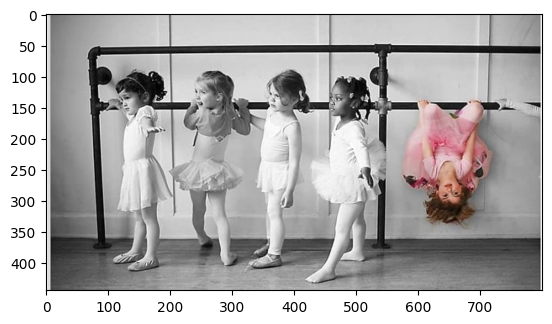

In [14]:
img = cv2.imread('Perspectiva.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

<img src="image-20250429-215346.png" width="" align="" />

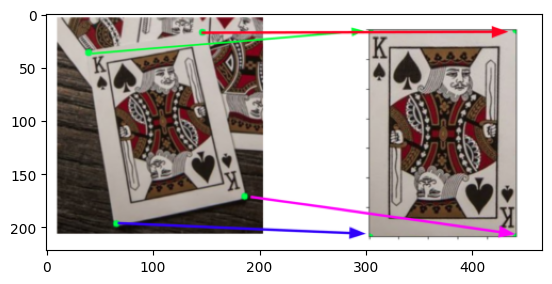

In [38]:
img = cv2.imread('cambio-perspectiva.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

3. Finalmente, vamos a aplicarla con `cv2.wrapPerspective()`, que va a extraer el area delimitada en la imagen original y aplicar la matriz de cambio de perspectiva para generar una imagen única recortada y con una nueva alineación.

<img src="image-20250429-215823.png" width="" align="" />

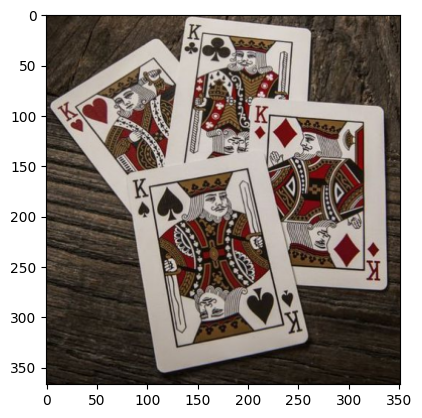

In [47]:
# Comencemos abriendo la imagen
img = cv2.cvtColor(cv2.imread("cards.jpg"), cv2.COLOR_BGR2RGB)
plt.imshow(img);

In [50]:
img.shape

(367, 351, 3)

Ahora vamos a identificar, a ojo, las coordenadas de las esquinas de la carta que queremos extraer y cambiar de perspectiva:

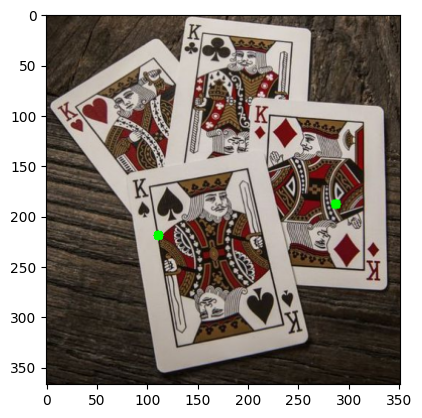

In [53]:
# Primero coordenada x, despues coordenada y
corners = [(111, 219), # Superior izquierdo
           (287, 188), # Inferior izquierdo
           (154, 482), # Superior derecho
           (352,  440) # Inferior derecho
          ]

for x, y in corners:
    cv2.circle(img, (x,y), radius=0, color=(0, 255, 0), thickness=10)
plt.imshow(img);

Creamos la matriz de cambio de perspectiva. Para eso, especificamos los puntos originales y a donde va a ir cada uno en la imagen final. Debemos decidir el tamaño de la imagen final

In [56]:
w, h = 250, 350

In [59]:
pts1 = np.float32(corners)
# Para los puntos de destino, debe preservarse el orden de los puntos originales
pts2 = np.float32([[0, 0], [w, 0], [0, h], [w, h]])

In [62]:
# Obtenemos la matriz de cambio de perspectiva
matrix = cv2.getPerspectiveTransform(pts1, pts2)

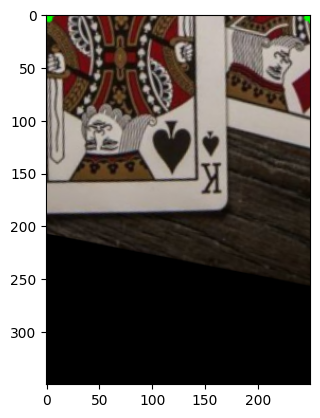

In [65]:
# Y la aplicamos con warpPerspective
# El segundo parametro es esta matriz y el tercero debe ser una tupla con especificando (ancho, alto)
img_output = cv2.warpPerspective(img, matrix, (w, h))
plt.imshow(img_output);

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=9be9d3e5-4f25-48e6-912d-b59b8644d952' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>